In [1]:
import torch
import torchvision.transforms as transforms
import torchvision
import io
import json
import argparse
import configparser
from PIL import Image
from tqdm import tqdm
import os

try: import torch_xla.core.xla_model as xm
except: pass

from utils.EBM_models import create_ebm
from utils.Diff_models import create_diff
from diffusers import UNet2DModel, DDPMScheduler
from utils.utils_purify import *

from utils.utils import *
from utils.utils_clf import *
from utils.utils_baselines import *

try: import torch_xla.core.xla_model as xm
except: pass

device = xm.xla_device()
os.environ['XRT_TPU_CONFIG'] = 'localservice;0;localhost:51011'

/home/sunaybhat/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
parser = argparse.ArgumentParser(description='PyTorch Poison Attack')

### Setup Arguments ###
parser.add_argument('--remote_user', default='sunaybhat', type=str, help='username for the remote server (TPU only, else pass in full directory args below)')
parser.add_argument('--num_proc', type=int, default=8, help='number of processes for TPU')
parser.add_argument('--config_file', default='./Configs/config.ini', type=str, help='path to the config file')
parser.add_argument('--config_overrides', default=None, nargs='+', type=str, help='Config Overrides (will execute in order)')
parser.add_argument('--exp_name', default=None, type=str,help='name of the experiment to append to the output dataframe')
parser.add_argument('--start_target_index', default=0, type=int,help='start label for the attack (only used for from_scratch attacks)')
parser.add_argument('--selected_indices', default=None, nargs='+', type=int, help='Specific indices to run the attack on each TPU core (default: None, TPU only!!!)')
parser.add_argument('--verbose','--v', default=False, action='store_true',help='print out additional information when running')

### Experiment Arguments ###
parser.add_argument('--dataset', default='cifar10', type=str, choices=['cifar10','cinic10','stl10','tinyimagenet'],help='dataset to use')
parser.add_argument('--data_key', default='Baseline', type=str, help='key for the purified or baseline data')
parser.add_argument('--model', default='HLB_S', type=str, choices=['HLB_S','HLB_M','HLB_L','ResNet18_HLB','ResNet18','ResNet34','MobileNetV2','DenseNet121'],help='type of model to use')
parser.add_argument('--poison_mode', default='from_scratch', type=str, choices=['from_scratch','clean','linear_transfer','fine_tune_transfer'],help='mode of attack')
parser.add_argument('--poison_type', default='Narcissus', type=str, choices=['Narcissus','NeuralTangent','GradientMatching','BullseyePolytope','BullseyePolytope_Bench'],help='type of poison to generate')
parser.add_argument('--baseline_defense', default='None', type=str, choices=['None','JPEG','Epic','Friendly'],help='type of defense to use')

### EBM Filter Arguments ###
parser.add_argument('--ebm_filter', default=None, type=float, help='EBM highest energy % to purify')
parser.add_argument('--path', default='PureGen_Models/EBMSNGAN32/cinic10_imagenet_nf[128].pt', type=str, help='path to the EBM model')

### Poison Arguments ###
parser.add_argument('--noise_sz_narcissus', default=32, type=int, help='size of the noise trigger for Narcissus')
parser.add_argument('--noise_eps_narcissus', default=8, type=int, help='epsilon for the noise trigger for Narcissus')

### Baseline Defense Arguments ###
parser.add_argument('--friendly_noise_type', default=['friendly','bernoulli'], type=str, nargs='*', help='type of noise to apply', choices=["uniform", "gaussian", "bernoulli", "gaussian_blur", "friendly"])
parser.add_argument('--epic_subset_size', type=float, help='size of the subset', default=0.1)
parser.add_argument('--epic_drop_after', type=int, help='epoch to start dropping', default=10)

#### Parse the arguments
args = parser.parse_args(['--model','ResNet18'])

### Read the config file
config = configparser.ConfigParser()
config.read(args.config_file)

# Set the arguments from the config file
set_args_from_config(args, config, 'DEFAULTS')
if args.poison_mode == 'linear' and not args.fine_tune: set_args_from_config(args, config, 'LINEAR_TRANSFER')
elif args.poison_mode == 'fine_tune' and args.fine_tune: set_args_from_config(args, config, 'FINE_TUNE')
if args.config_overrides is not None:
    for config_override in args.config_overrides:
        set_args_from_config(args, config, config_override)

### Error Checking
check_arg_errors(args)

# Setup the directories
setup_directories(args)


In [17]:
base_data,_ = get_base_poisoned_dataset(args,0, transforms.Compose([transforms.ToTensor()]),device,ebm_model=None)
unpurified_data = base_data

# base_data = replace_high_energy_samples(purified_loader, unpurified_loader, ebm_model, args.ebm_filter,device)

In [4]:
ebm_model = create_ebm("EBM", num_filters=32)
ebm_model.load_state_dict(torch.load("/home/sunaybhat/data/PureGen_Models/EBM/cinic10_imagenet_ep120_nf32.pt"))
ebm_model = ebm_model.to(device)

Replacing High Energy Samples: 100%|█████████▉| 49988/50000 [02:08<00:00, 385.28it/s]

ValueError: zero-dimensional arrays cannot be concatenated

In [30]:
indices.shape

torch.Size([5000])

In [35]:
unpurified_data.data[1]

(<PIL.Image.Image image mode=RGB size=32x32>, tensor(0), tensor(1), tensor(1))

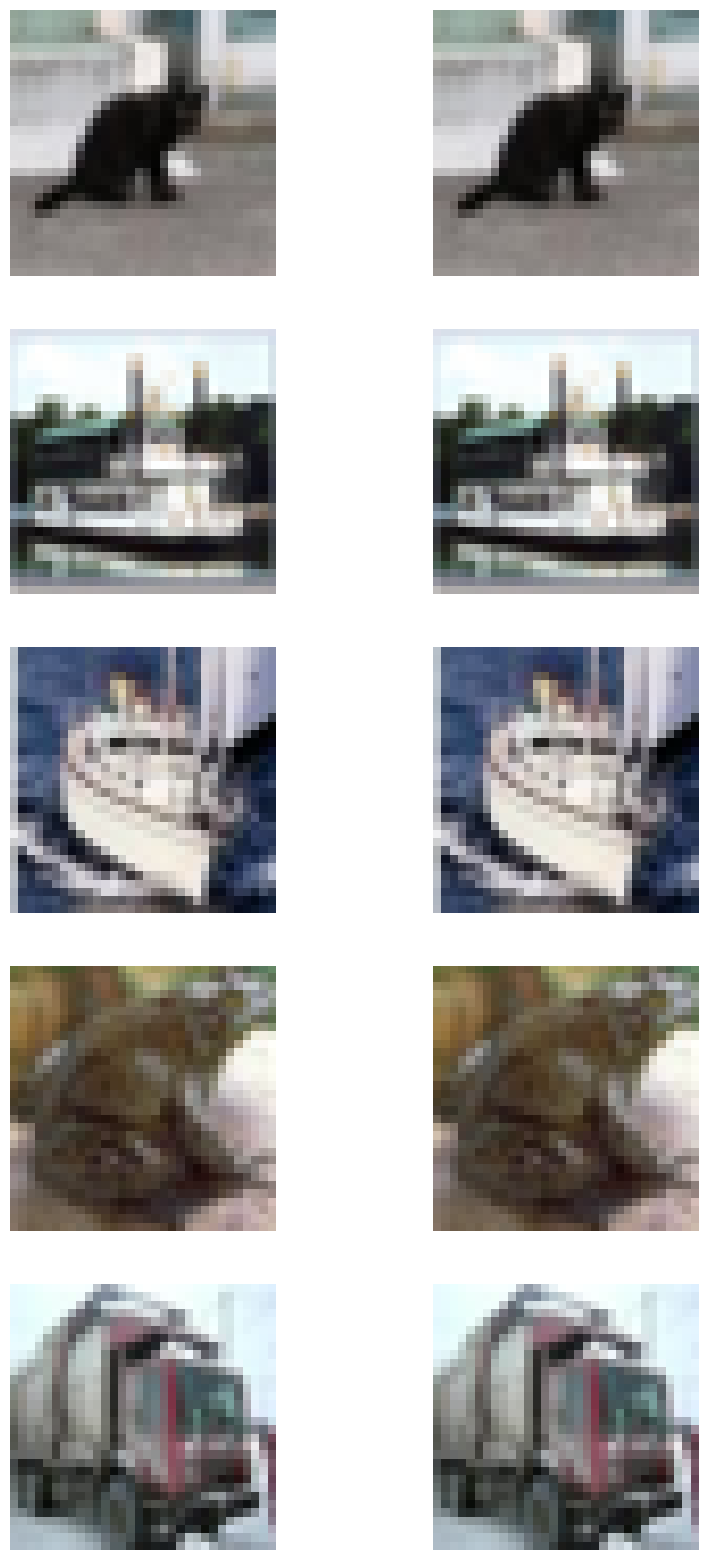

: 

In [36]:

import matplotlib.pyplot as plt
# Slect 5 random indices and plot sam eindices from both datasets sid by side
fig, ax = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):

    idx = np.random.randint(0, len(unpurified_data.data))
    ax[i, 0].imshow(unpurified_data.data[idx][0])
    ax[i, 1].imshow(base_data.data[idx][0])
    
    ax[i, 0].axis('off')
    ax[i, 1].axis('off')

    

In [4]:
# Load in 16 test samples from cifar-10
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_data = torchvision.datasets.CIFAR10(root='/home/sunaybhat/data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=False)
test_data = next(iter(test_loader))
test_images = test_data[0]

Files already downloaded and verified


In [20]:
### Pretrained
# model_id = "google/ddpm-cifar10-32"
# diff_model = UNet2DModel.from_pretrained("google/ddpm-cifar10-32")
# scheduler = DDPMScheduler.from_pretrained("google/ddpm-cifar10-32")

### Trained
# diff_model = create_diff("DM_UNET", unet_channels=(32, 32, 64, 64, 128, 128), nf=32)
# diff_model.load_state_dict(torch.load("/home/sunaybhat/data/PureGen_Models/DM_UNET/cinic10_imagenet_DDPM[150]_nf[(32, 32, 64, 64, 128, 128)].pt"))
# scheduler = DDPMScheduler(num_train_timesteps=1000)

#### EBM Guided
ebm_model = create_ebm("EBM", num_filters=32)
ebm_model.load_state_dict(torch.load("/home/sunaybhat/data/PureGen_Models/EBM/cinic10_imagenet_ep120_nf32.pt"))
ebm_model = ebm_model.to(device)
ebm_model.eval();

diff_model = create_diff("DM_UNET", unet_channels=(32, 32, 64, 64, 128, 128), nf=32)
diff_model.load_state_dict(torch.load("/home/sunaybhat/data/PureGen_Models/DM_UNET/cinic10_imagenet_GUIDED_EBM[cinic10_imagenet_ep120_nf32]_BANK[Size320_Batch32]_MCMC[Steps100_Temp0.0001]_nf[(32, 32, 64, 64, 128, 128)].pt"))


### GENERAL
num_params = sum(p.numel() for p in diff_model.parameters() if p.requires_grad)
print(f"Number of parameters: {num_params}")

diff_model = diff_model.to(device)
diff_model.eval();


Number of parameters: 7126275


100%|██████████| 125/125 [00:26<00:00,  4.75it/s]


(-0.5, 137.5, 137.5, -0.5)

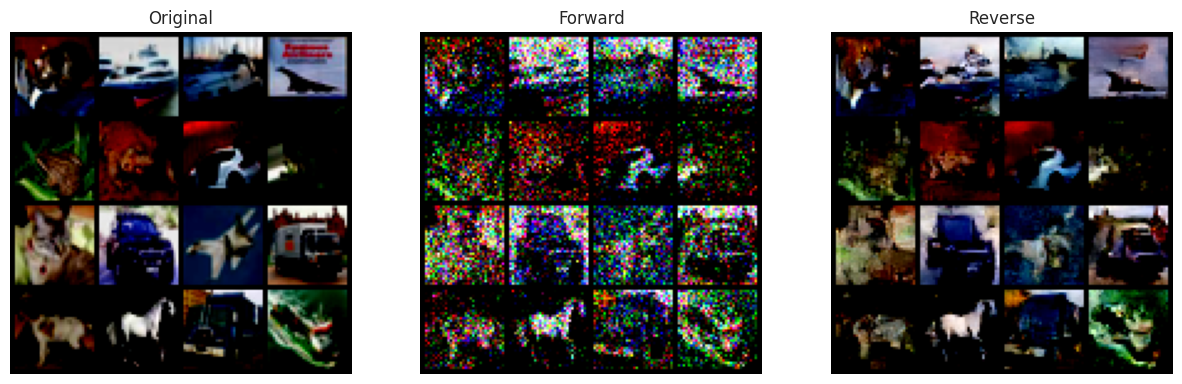

In [10]:
Steps = 125

# Run forward process on test_data using diffuser
forward_images = scheduler.add_noise(test_images,torch.randn(test_images.shape),timesteps = torch.LongTensor([Steps])).to(device)


reverse_images = forward_images

for i, t in enumerate(tqdm(scheduler.timesteps[-Steps:])):
    # 1. predict noise residual
    with torch.no_grad():
        residual = diff_model(reverse_images, t).sample

    # 2. compute previous image and set x_t -> x_t-1
    reverse_images = scheduler.step(residual, t, reverse_images).prev_sample

    xm.mark_step()

forward_images = forward_images.detach().cpu()
reverse_images = reverse_images.detach().cpu()

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
# Plot original, forward, and reverse
fig,axs = plt.subplots(1,3,figsize=(15,5))

# Plot all images, use torch grid
axs[0].imshow(torchvision.utils.make_grid(test_images, nrow=4).permute(1,2,0))
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(torchvision.utils.make_grid(forward_images.cpu(), nrow=4).permute(1,2,0))
axs[1].set_title("Forward")
axs[1].axis("off")

axs[2].imshow(torchvision.utils.make_grid(reverse_images.cpu(), nrow=4).permute(1,2,0))
axs[2].set_title("Reverse")
axs[2].axis("off")


(-0.5, 137.5, 137.5, -0.5)

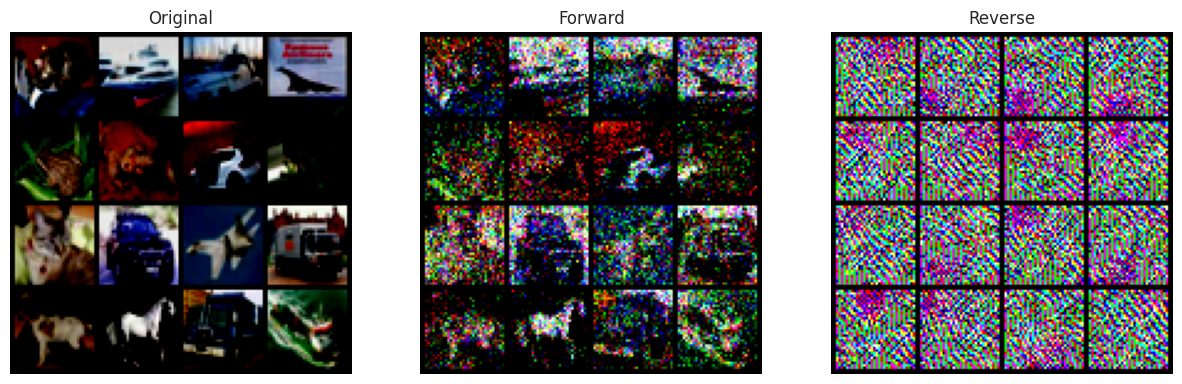

: 

In [21]:
Steps = 125

# Run forward process on test_data using diffuser
purified_images = ebm_purify(ebm_model,test_images.to(device),300,langevin_temp=1e-4)

reverse_images = purified_images.clone()

with torch.no_grad():
    for steps in reversed(range(300)):
        t_s = torch.ones(reverse_images.shape[0],device=device) * steps
        X_eps = diff_model(reverse_images, timestep=t_s,return_dict=False)[0]
        reverse_images = reverse_images + X_eps
        xm.mark_step()

forward_images = forward_images.detach().cpu()
reverse_images = reverse_images.detach().cpu()

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
# Plot original, forward, and reverse
fig,axs = plt.subplots(1,3,figsize=(15,5))

# Plot all images, use torch grid
axs[0].imshow(torchvision.utils.make_grid(test_images, nrow=4).permute(1,2,0))
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(torchvision.utils.make_grid(forward_images.cpu(), nrow=4).permute(1,2,0))
axs[1].set_title("Forward")
axs[1].axis("off")

axs[2].imshow(torchvision.utils.make_grid(reverse_images.cpu(), nrow=4).permute(1,2,0))
axs[2].set_title("Reverse")
axs[2].axis("off")
